# Single-cell Hi-C — scHiCluster impute + cell-cycle UMAP

End-to-end tutorial showing how to go from a multi-cell `.scool` bundle to a
cell-embedding plot coloured by cell-cycle phase, using `epione.single.hic`.

**Pipeline.** For each cell we densify a sparse contact matrix per chromosome
via [scHiCluster](https://www.pnas.org/doi/10.1073/pnas.1901423116) (Zhou et al. 2019, PNAS):
linear convolution → random walk with restart → top-k filter. Each cell is
then a flattened upper-triangle feature vector; PCA gives a low-dim cell
embedding, scanpy gives UMAP / clustering downstream.

**Data.** ~105 mouse-ES cells from
[Nagano *et al.* 2017](https://www.nature.com/articles/nature23001),
downloaded from
[Zenodo 3557682](https://zenodo.org/records/3557682) (multi-cell `.scool`
at 1 Mb resolution, 327 MB) joined with cell-cycle phase from GEO
[GSE94489](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE94489).

**Time.** ~4 min on a Sherlock CPU node (105 cells × 20 chromosomes;
imputation dominates). The imputed `.npz` directory is cached so re-runs
are <2 s.


## 1 · Setup


In [1]:
import pathlib
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

import epione as epi
epi.pl.plot_set()

DATA = pathlib.Path('/scratch/users/steorra/data/sc-hic-nagano')
SCOOL = DATA / 'nagano_1MB_raw.scool'
FEATURES = DATA / 'GSE94489_2i_diploids_features_table.txt.gz'
README = DATA / 'GSE94489_README.txt'
OUT = pathlib.Path('result/t_sc_hic_basics')
OUT.mkdir(parents=True, exist_ok=True)
IMPUTED = OUT / 'imputed'

print(f'scool   : {SCOOL.exists()}  ({SCOOL.stat().st_size/1e6:.1f} MB)')
print(f'features: {FEATURES.exists()}')
print(f'README  : {README.exists()}')


└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

scool   : True  (326.6 MB)
features: True
README  : True


If any of those paths are missing, run the download recipe in
`epione_guide/tutorials/single/data_sc_hic_nagano.md` (or just `wget`
the three URLs into `DATA`). Everything below is reproducible from a
freshly-downloaded scool.


## 2 · Build the cell metadata table

Two things to bridge:

* the `.scool` indexes cells by `<Nature_Reference_ID>_<5p>_<3p>_R1fastqgz`
  (e.g. `Diploid_11_CGTACTAG_AAGGAGTA_R1fastqgz`),
* the GEO features table indexes cells by `cell_nm` like `1CDU_1`.

The README file maps both back to a barcode triple. We join via that.


In [2]:
readme = pd.read_csv(README, sep='\t', dtype=str)
# README has dashes in `Name` (e.g. 1CDU-1); features uses underscores.
readme['cell_nm_us'] = readme['Name'].str.replace('-', '_', regex=False)

features = pd.read_csv(FEATURES, sep='\t')
features = features[features['passed_qc'] == 1].copy()

joined = features.merge(
    readme[['Nature_Reference_ID', 'Five_prime_barcode',
            'Three_prime_barcode', 'cell_nm_us']],
    left_on='cell_nm', right_on='cell_nm_us', how='inner',
)
joined['scool_name'] = (
    joined['Nature_Reference_ID'] + '_' + joined['Five_prime_barcode']
    + '_' + joined['Three_prime_barcode'] + '_R1fastqgz'
)

# Restrict to cells actually in the scool, with enough contacts
# to make per-cell impute meaningful.
with h5py.File(SCOOL, 'r') as h:
    avail = set(h.keys())
joined = joined[joined['scool_name'].isin(avail)]
joined = joined[joined['total_contacts'] > 5_000].reset_index(drop=True)

print(f'cells with metadata + scool entry + ≥5 k contacts: {len(joined):,}')
print(joined['group'].value_counts().to_string())


cells with metadata + scool entry + ≥5 k contacts: 1,473
group
early-S      676
late-S/G2    406
G1           348
pre-M         25
post-M        18


## 3 · Stratified subset (35 × 3 phases)

We subsample to 35 cells per phase across the three major populations
(`G1` / `early-S` / `late-S/G2`) so the run finishes in a few minutes.
Mitotic phases (`pre-M` / `post-M`) are interesting biologically but each
has fewer than 30 QC-passing cells in this scool — leave them for the
advanced tutorial.


In [3]:
KEEP_PHASES = ['G1', 'early-S', 'late-S/G2']
stratified = (joined[joined['group'].isin(KEEP_PHASES)]
              .groupby('group', group_keys=False)
              .apply(lambda g: g.sample(min(35, len(g)), random_state=0)))
stratified = stratified.reset_index(drop=True)
print(stratified['group'].value_counts().to_string())
stratified[['cell_nm', 'group', 'total_contacts',
            'repli_score', 'scool_name']].head()


group
G1           35
early-S      35
late-S/G2    35


,cell_nm,group,total_contacts,repli_score,scool_name
0,1CDU_37,G1,75526,1.111489,Diploid_11_ATGCGCAG_TTATGCGA_R1fastqgz
1,1CDU_602,G1,73189,1.074751,Diploid_12_TGCAGCTA_CCTAGAGT_R1fastqgz
2,1CDX1_337,G1,191883,1.164930,Diploid_20_GTAGAGGA_TATCCTCT_R1fastqgz
3,1CDU_574,G1,231114,1.096250,Diploid_12_TACGCTGC_GAGCCTTA_R1fastqgz
4,1CDX1_393,G1,278776,1.071397,Diploid_20_ATGCGCAG_CTATTAAG_R1fastqgz


## 4 · Load + glance at one raw cell

`load_scool_cells` returns an AnnData with one row per cell and zero
features (the contacts live in the `.scool`, not in `adata.X`). We pass
the metadata along so downstream plots can colour by phase.


In [4]:
# All 19 mouse autosomes + chrX. The Nagano scool also has chr*_random
# / chrUn etc. — exclude those to keep the imputed feature dimension
# focused on real chromosomes.
CHROMS = [f'chr{i}' for i in range(1, 20)] + ['chrX']

adata = epi.single.hic.load_scool_cells(
    SCOOL,
    cell_names=stratified['scool_name'].tolist(),
    obs=stratified[['group', 'total_contacts', 'repli_score']],
    chromosomes=CHROMS,
)
print(adata)


AnnData object with n_obs × n_vars = 105 × 0
    obs: 'cool_path', 'group', 'total_contacts', 'repli_score'
    uns: 'hic'


demo cell: Diploid_26_CGATCAGT_TTATGCGA_R1fastqgz  total_contacts: 570,676


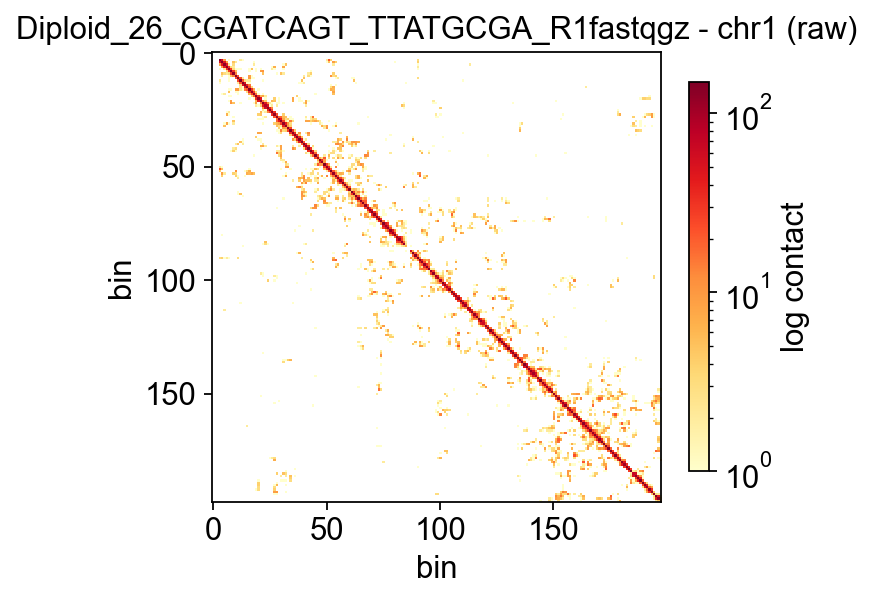

In [5]:
# A single raw cell at 1 Mb is *very* sparse — perfect to motivate why
# we need to impute. Pick the most-deeply-sequenced cell so the diagonal
# isn't pure noise.
demo_cell = adata.obs['total_contacts'].astype(float).idxmax()
fig, ax = epi.pl.plot_cell_contacts(
    adata, cell_id=demo_cell, chromosome='chr1',
    use_imputed=False, log=True, figsize=(4.5, 4),
)
print(f'demo cell: {demo_cell}  total_contacts: '
      f'{int(adata.obs.loc[demo_cell, "total_contacts"]):,}')
plt.show()


## 5 · Impute every cell (scHiCluster)

`impute_cells` runs three operations per (cell × chromosome):
linear convolution (`pad=1` → 3×3 sum kernel), random walk with restart
(`α=0.05` → ~20-step diffusion), top-k filter (`top_pct=0.05` → keep top
5 % of values). Each cell × 20 chroms × 1 Mb ≈ 1 s; the result is
written to `<IMPUTED>/<cell>.npz` and the call is **idempotent** —
`overwrite=False` (default) skips cells already on disk so re-running
the cell takes <1 s.


In [6]:
epi.single.hic.impute_cells(
    adata,
    out_dir=IMPUTED,
    pad=1, rwr_alpha=0.05, top_pct=0.05,
    progress=True,
)
print(f'imputed dir: {adata.uns["hic"]["imputed_dir"]}')


impute_cells:   0%|          | 0/105 [00:00<?, ?it/s]

imputed dir: result/t_sc_hic_basics/imputed


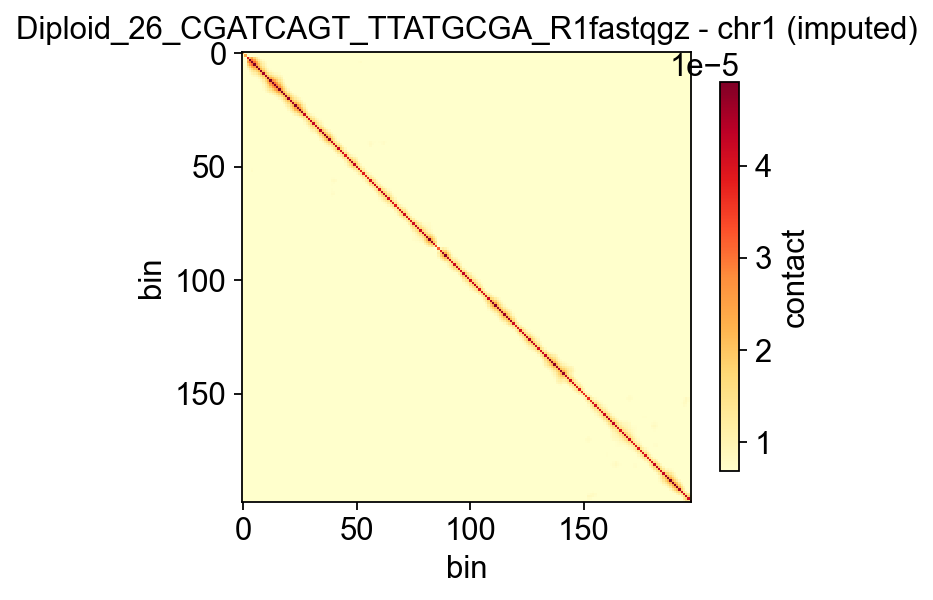

In [7]:
# Same cell + same chromosome as the raw view above — the imputed matrix
# now has a clear diagonal + visible off-diagonal density (TAD-scale
# blocks on chr1).
fig, ax = epi.pl.plot_cell_contacts(
    adata, cell_id=demo_cell, chromosome='chr1',
    use_imputed=True, log=False, figsize=(4.5, 4),
)
plt.show()


## 6 · Cell embedding (PCA on imputed contacts)

`embedding` reads every cell's `.npz`, flattens the upper triangle of
every chromosome (excluding the diagonal), drops zero-variance features,
z-scores, and runs PCA. Output is a fresh AnnData where
`obsm['X_pca']` is the cell embedding.


In [8]:
embed = epi.single.hic.embedding(
    adata, n_components=20, standardise=True,
)
print(embed)
print(f'feature dim (after dropping zero-var bins): {embed.X.shape[1]:,}')
print(f'PC1–5 variance ratio: '
      f'{np.round(embed.uns["pca"]["variance_ratio"][:5], 3)}')


AnnData object with n_obs × n_vars = 105 × 40604
    obs: 'cool_path', 'group', 'total_contacts', 'repli_score'
    uns: 'hic', 'pca'
    obsm: 'X_pca'
feature dim (after dropping zero-var bins): 40,604
PC1–5 variance ratio: [0.156 0.044 0.041 0.035 0.031]


## 7 · PCA scatter coloured by phase

If imputation worked, cells from different phases should already separate
on PC1 / PC2. ANOVA gives a quantitative check: F-statistic comparing
between-phase to within-phase variance.


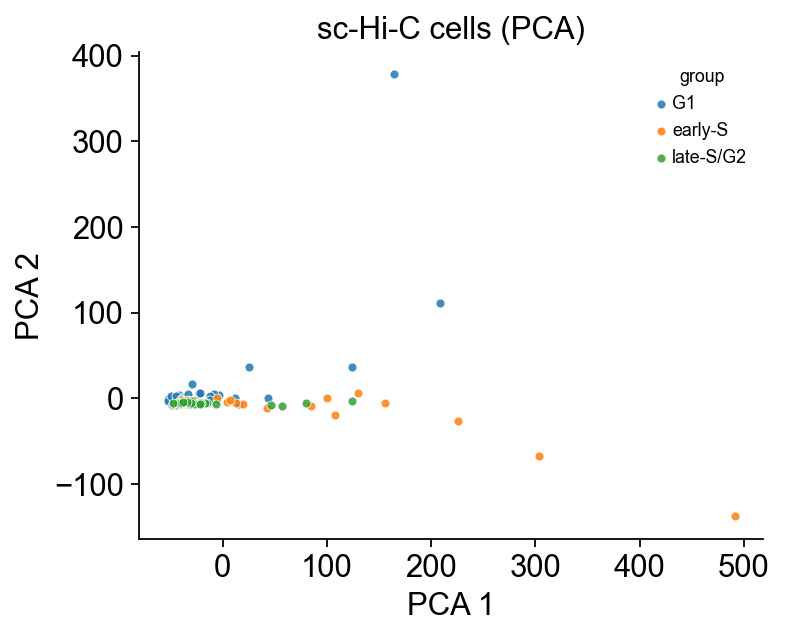

In [9]:
fig, ax = epi.pl.plot_embedding(
    embed, basis='X_pca', components=(1, 2),
    color='group', cmap='tab10',
    figsize=(5.0, 4.0),
)
plt.show()


In [10]:
from scipy.stats import f_oneway
for k in (0, 1, 2):
    by = [embed.obsm['X_pca'][embed.obs['group'] == g, k]
          for g in KEEP_PHASES]
    F, p = f_oneway(*by)
    means = ', '.join(f'{g}={v.mean():+.2f}' for g, v in zip(KEEP_PHASES, by))
    print(f'PC{k+1}: F={F:5.2f}  p={p:.2e}   means: {means}')


PC1: F= 3.34  p=3.92e-02   means: G1=-9.13, early-S=+27.41, late-S/G2=-18.28
PC2: F= 4.20  p=1.77e-02   means: G1=+16.10, early-S=-10.72, late-S/G2=-5.38
PC3: F= 0.69  p=5.04e-01   means: G1=+6.25, early-S=-5.04, late-S/G2=-1.21


## 8 · UMAP

Add scanpy's `sc.pp.neighbors` + `sc.tl.umap` on top of the PCA. UMAP
doesn't add new biology — it just makes the cell-cycle gradient more
visible in 2D for small panels.


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)


computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)


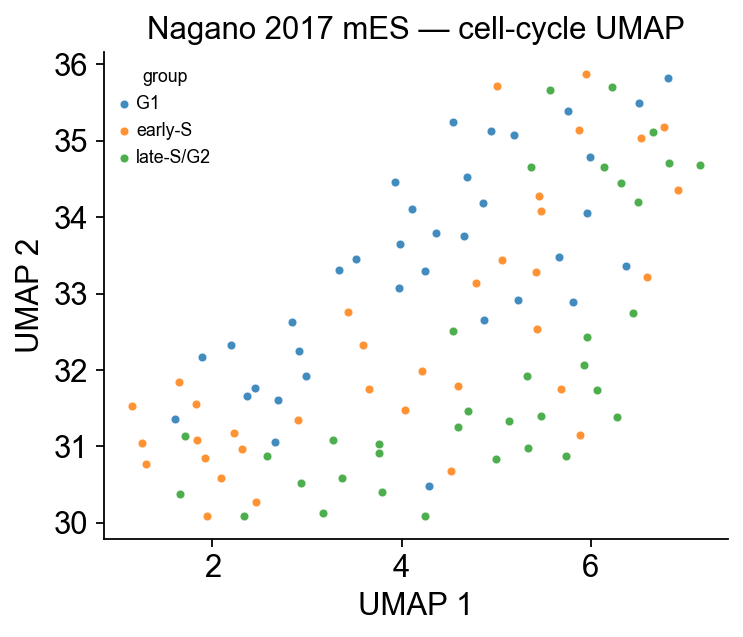

In [11]:
import scanpy as sc
sc.pp.neighbors(embed, n_neighbors=15, use_rep='X_pca')
sc.tl.umap(embed, min_dist=0.4, random_state=0)

fig, ax = epi.pl.plot_embedding(
    embed, basis='X_umap', components=(1, 2),
    color='group', cmap='tab10',
    figsize=(5.0, 4.0), title='Nagano 2017 mES — cell-cycle UMAP',
)
plt.show()


## 9 · Replication-score gradient

The features table also has a per-cell `repli_score` (DNA-replication
timing, derived from contact decay). Colouring the same UMAP by
`repli_score` should produce a **continuous** gradient consistent with
the discrete phase labels — early-S cells with high repli-score sit
at one end, G1 / late-S/G2 with low score at the other.


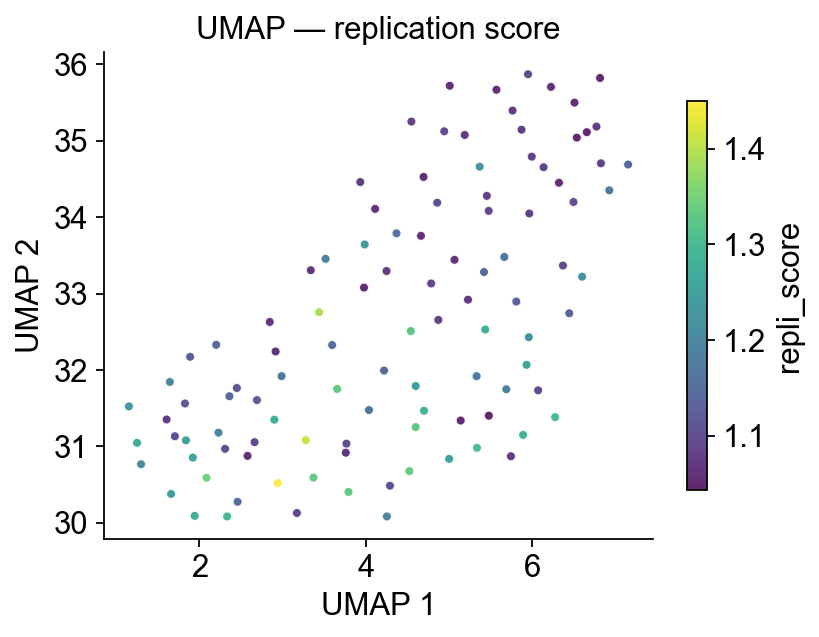

In [12]:
fig, ax = epi.pl.plot_embedding(
    embed, basis='X_umap', components=(1, 2),
    color='repli_score',
    figsize=(5.5, 4.0),
    title='UMAP — replication score',
)
plt.show()


## 10 · Summary + next steps

**This tutorial covered the full sc-Hi-C analysis loop with `epione.single.hic`:**

1. `load_scool_cells` — index a multi-cell `.scool` (incl. legacy
   HiCMatrix layout) into an AnnData.
2. `impute_cells` — densify each cell × chromosome via scHiCluster
   (linear-conv + RWR + top-k); idempotent caching so re-runs are free.
3. `embedding` — PCA on flattened imputed contacts, ready for scanpy
   downstream (`sc.pp.neighbors`, `sc.tl.umap`, `sc.tl.leiden`).
4. `plot_embedding`, `plot_cell_contacts` — diagnostic visualisation.

**Phase 2 will add:** Leiden clustering with cluster-specific contact
metaplots, multi-resolution embedding (1 Mb + 100 kb), and a sn-m3C-seq
case study (Liu *et al.* 2021 mouse cortex) coupling sc-Hi-C cell types
with single-cell methylation.
